
# K-Means Clustering on High-Dimensional Data

## Objective
Understand how to work with high-dimensional data using K-Means and PCA visualization.

## Dataset
`kmeans_highdim.csv`

## Tasks
- Apply K-Means clustering
- Use Principal Component Analysis (PCA) to reduce data to 2D
- Visualize clusters after PCA projection

## Questions
1. Why is PCA needed for visualization?
2. Are clusters clearly visible after projection?
3. Does dimensionality reduction affect interpretation?


In [1]:

# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("Libraries imported successfully")


Libraries imported successfully


In [2]:

# Load dataset

data = pd.read_csv("kmeans_highdim.csv")

print("First 5 rows of dataset:")
display(data.head())

print("\nDataset shape:", data.shape)


First 5 rows of dataset:


,F1,F2,F3,F4,F5,F6
0,-7.840318,4.427268,4.110675,4.021862,-8.480127,8.358291
1,7.866011,-4.231902,-5.365190,-6.763530,-3.511425,0.470933
2,6.461709,-4.767488,-5.176115,-3.742346,-3.335522,0.820925
3,-1.006841,9.088381,6.268494,0.593068,-8.583010,-6.935657
4,-0.050791,-2.779733,1.674890,-7.419345,-5.840545,-3.478633



Dataset shape: (400, 6)


In [ ]:

# Dataset information

print("Dataset Info")
print(data.info())

print("\nStatistical Summary")
display(data.describe())



## Step 1: Select Features

For clustering, we use only numerical columns.  
If the dataset contains a target or label column, remove it before clustering.


In [3]:

# Select only numeric columns

X = data.select_dtypes(include=[np.number]).copy()

print("Selected numerical features shape:", X.shape)
display(X.head())


Selected numerical features shape: (400, 6)


,F1,F2,F3,F4,F5,F6
0,-7.840318,4.427268,4.110675,4.021862,-8.480127,8.358291
1,7.866011,-4.231902,-5.365190,-6.763530,-3.511425,0.470933
2,6.461709,-4.767488,-5.176115,-3.742346,-3.335522,0.820925
3,-1.006841,9.088381,6.268494,0.593068,-8.583010,-6.935657
4,-0.050791,-2.779733,1.674890,-7.419345,-5.840545,-3.478633



## Step 2: Standardize the Features

K-Means is distance-based, so scaling is important.  
High-dimensional datasets may contain features with different ranges.


In [4]:

# Standardize data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data standardized successfully")
print("Scaled data shape:", X_scaled.shape)


Data standardized successfully
Scaled data shape: (400, 6)



## Step 3: Apply K-Means Clustering

Here we use **K = 3** as a starting point.  
You can change `n_clusters` based on your dataset or elbow method result.


In [5]:

# Apply K-Means

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

data["Cluster"] = clusters

print("Cluster labels:")
print(clusters[:20])

print("\nCluster counts:")
print(data["Cluster"].value_counts().sort_index())


Cluster labels:
[0 1 1 2 1 2 0 1 1 1 1 1 0 1 1 1 2 1 2 2]

Cluster counts:
Cluster
0    100
1    200
2    100
Name: count, dtype: int64


C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [ ]:

# K-Means inertia

print("K-Means Inertia / WCSS:", kmeans.inertia_)



## Step 4: Apply PCA to Reduce Data to 2D

PCA converts many features into two principal components:
- PC1 captures the maximum possible variance
- PC2 captures the next maximum variance perpendicular to PC1

This helps us plot high-dimensional data in a 2D graph.


In [6]:

# Apply PCA to reduce data into 2 dimensions

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clusters

print("PCA output:")
display(pca_df.head())

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance explained by PC1 and PC2:")
print(pca.explained_variance_ratio_.sum())


PCA output:


,PC1,PC2,Cluster
0,2.215043,0.874931,0
1,-2.587229,0.621089,1
2,-2.243299,0.678725,1
3,1.417193,-1.595231,2
4,-0.990427,-0.531691,1



Explained variance ratio:
[0.67795598 0.21296832]

Total variance explained by PC1 and PC2:
0.8909243030055418



## Step 5: Visualize Clusters in PCA 2D Space


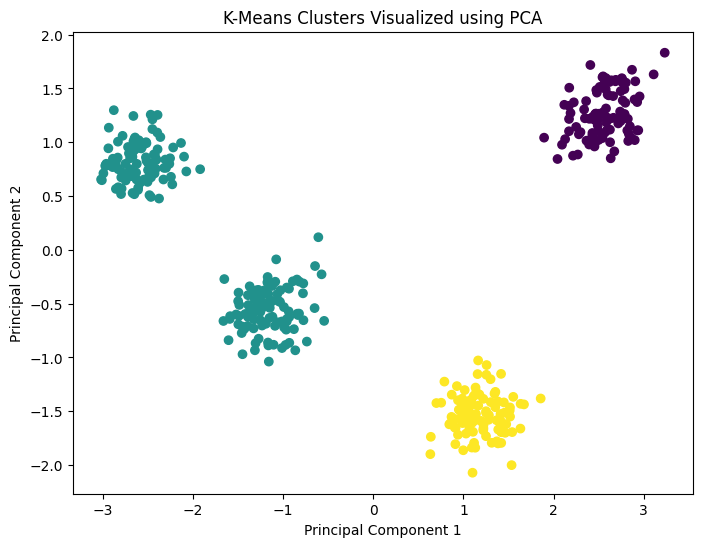

In [7]:

# Plot clusters after PCA projection

plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Visualized using PCA")

plt.show()



## Step 6: Optional - Visualize PCA Centroids

The centroids are learned in the original scaled feature space.  
To plot them in PCA space, we transform the centroids using the same PCA model.


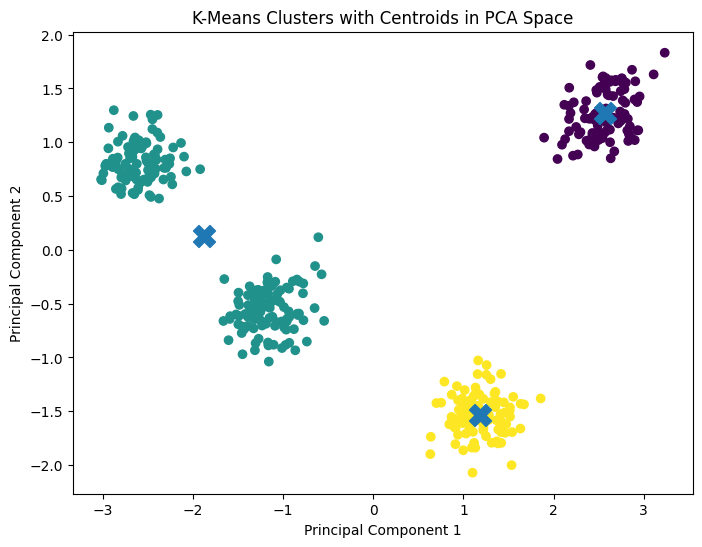

In [8]:

# Transform cluster centroids into PCA space

centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"]
)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker="X",
    s=250
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters with Centroids in PCA Space")

plt.show()



# Interpretation

High-dimensional data cannot be directly visualized because humans can easily understand only 2D or 3D plots.

PCA helps by projecting many features into two new axes.  
However, PCA is only a projection, so some information may be lost.

If PC1 and PC2 explain a high percentage of variance, the 2D plot gives a better representation.  
If explained variance is low, the plot may not show the real cluster structure clearly.



# Answers to Questions

## 1. Why is PCA needed for visualization?

PCA is needed because high-dimensional data has more than two or three features.  
A normal scatter plot can show only two features at a time.

PCA reduces many features into two principal components so we can visualize the overall structure in 2D.

---

## 2. Are clusters clearly visible after projection?

This depends on the PCA plot.

- If clusters are well separated in the PCA graph, then clustering structure is clearly visible.
- If clusters overlap, then the first two principal components may not capture enough information to separate the clusters clearly.

Check the explained variance ratio to understand how much information PC1 and PC2 captured.

---

## 3. Does dimensionality reduction affect interpretation?

Yes.

Dimensionality reduction can make visualization easier, but it can also lose some information.

The PCA plot does not show the full high-dimensional structure.  
So, PCA visualization should be used for understanding cluster patterns, but final interpretation should also consider original features and cluster statistics.


In [ ]:

# Optional: Analyze cluster-wise mean values in original feature space

cluster_summary = data.groupby("Cluster")[X.columns].mean()

print("Cluster-wise feature means:")
display(cluster_summary)
